# MOTOR 1: OTIMIZADOR DE TRAÇADO E GRAFOS VIÁRIOS (VLT)
# Objetivo: Calcular matematicamente a rota de menor custo e impacto pela malha real da cidade

In [28]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import networkx as nx
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import folium
import numpy as np

print("Ambiente Global configurado com sucesso!")

Ambiente Global configurado com sucesso!


Baixando malha viária de João Pessoa, Paraíba, Brazil... (Isso pode levar alguns segundos)


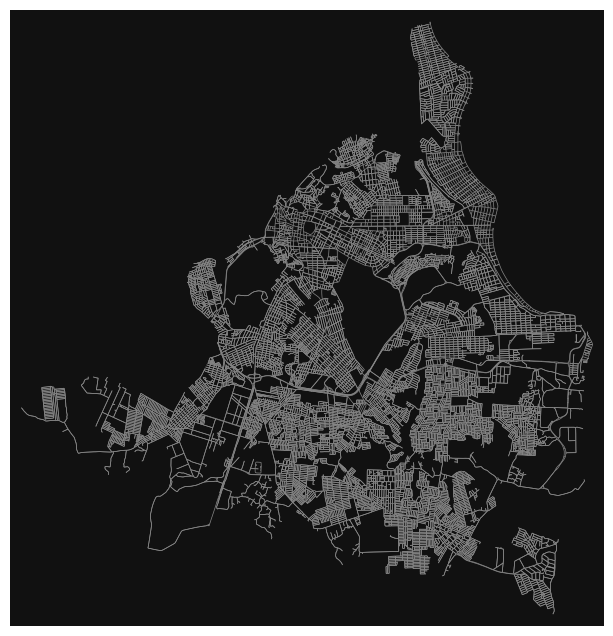

In [29]:
# Baixando ruas de qualquer lugar do mundo
cidade = "João Pessoa"
estado = "Paraíba"
# fiz essa separação pra conseguir puxar apenas cidade ao filtrar o arquivo do ibge por cidade
local_osmnx = f"{cidade}, {estado}, Brazil"
print(f"Baixando malha viária de {local_osmnx}... (Isso pode levar alguns segundos)")

# Baixa a rede de ruas para dirigir/VLT (drive)
grafo_ruas = ox.graph_from_place(local_osmnx, network_type='drive')

nos, arestas = ox.graph_to_gdfs(grafo_ruas)

# Plota o mapa de ruas na tela para visualizarmos
fig, ax = ox.plot_graph(grafo_ruas, node_size=0, edge_color="#888888", edge_linewidth=0.5)

In [30]:
# Lendo os dados
tags_ambientais = {
    'leisure': 'nature_reserve',
    'boundary': 'protected_area',
    'landuse': 'forest'
}
reservas = ox.features_from_place(cidade, tags=tags_ambientais)

# Ordena a tabela alfabeticamente pelo nome, jogando os NaN (vazios) para o final
reservas_organizadas = reservas.sort_values(by='name', na_position='last')
# Mostra apenas as colunas de nome e geometria para conferir
reservas_organizadas[['name']].head(6)

name
element  id                                                       
way      255739402       Floresta Nacional da Restinga de Cabedelo
         79127143                                Mata Externa UFPB
         1462395915   Refúgio de Vida Silvestre Mata do Buraquinho
         1462397439  Área de Proteção Ambiental Naufrágio Queimado
relation 5371614                                               NaN
         12847166                                              NaN

In [31]:
# Plotando mapa de preservação
mapa_reservas = folium.Map(location=[-7.1150, -34.8906], zoom_start=12)

folium.GeoJson(
    reservas,
    name='Áreas Verdes e Reservas',
    style_function=lambda x: {
        'fillColor': 'green',
        'color': 'black',
        'weight': 1,
        'fillOpacity': 0.6
    },
    tooltip=folium.GeoJsonTooltip(fields=['name'], aliases=['Nome:'])
).add_to(mapa_reservas)

folium.LayerControl().add_to(mapa_reservas)
mapa_reservas


In [32]:
arq_relevo = rasterio.open('dados/relevo_jp.tif')

# traduz pro interpolate funcionar (metros)
arestas = arestas.to_crs(epsg=31985)
pts_inicio = arestas.geometry.interpolate(0.0, normalized=True)
pts_meio = arestas.geometry.interpolate(0.5, normalized=True)
pts_fim = arestas.geometry.interpolate(1.0, normalized=True)
# traduz de volta pro crs original (graus)
pts_inicio = pts_inicio.to_crs(arq_relevo.crs)
pts_meio = pts_meio.to_crs(arq_relevo.crs)
pts_fim = pts_fim.to_crs(arq_relevo.crs)

coords_inicio = list(zip(pts_inicio.x, pts_inicio.y))
coords_meio = list(zip(pts_meio.x, pts_meio.y))
coords_fim = list(zip(pts_fim.x, pts_fim.y))

arestas['alt_inicio'] = [dado[0] for dado in arq_relevo.sample(coords_inicio)]
arestas['alt_meio'] = [dado[0] for dado in arq_relevo.sample(coords_meio)]
arestas['alt_fim'] = [dado[0] for dado in arq_relevo.sample(coords_fim)]


meia_distancia = arestas['length'] / 2

arestas['inclinacao_1'] = (abs(arestas['alt_meio'] - arestas['alt_inicio']) / meia_distancia) * 100
arestas['inclinacao_2'] = (abs(arestas['alt_fim'] - arestas['alt_meio']) / meia_distancia) * 100


arestas[['name', 'highway', 'inclinacao_1', 'inclinacao_2']].head()

name      highway  \
u         v          key                                                    
324817308 7187131525 0        Rodovia Governador Mário Covas        trunk   
          3552601996 0                        Rua Domésticas  residential   
324817350 2052120227 0                                   NaN   trunk_link   
          1869474390 0      Rodovia Governador Antônio Mariz        trunk   
337591192 818939265  0    Rua Lionildo Francisco de Oliveira  residential   

                          inclinacao_1  inclinacao_2  
u         v          key                              
324817308 7187131525 0        0.981317      3.653591  
          3552601996 0        0.946334      3.814838  
324817350 2052120227 0        9.484135      4.268390  
          1869474390 0        7.832776      1.923041  
337591192 818939265  0        2.083436      2.929796

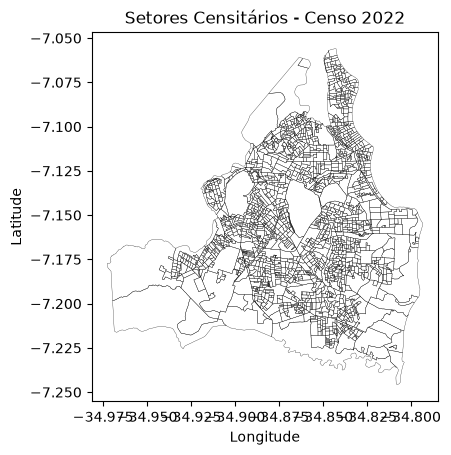

In [ ]:
# mapa de calor (senso e pgv)
datapath_senso = 'dados/dados_ibge_senso/PB_setores_CD2022.shp'
filter =  f"NM_MUN = '{cidade}'"
setores = gpd.read_file(datapath_senso, where=filter)


setores.head()

In [34]:
# adicionando os pesos nas ruas
arestas['edge_weight'] = arestas['length']

# fator inclinacao
arestas['edge_weight'] = np.where(
    (arestas['inclinacao_1'] > 6.0) | (arestas['inclinacao_2'] > 6.0), #condição
    float('inf'), #true (infinito)
    arestas['edge_weight'] #false (mantem)
)
# fator desapropriação
arestas['edge_weight'] = np.where(
    arestas['highway'] == 'residential', #condição
    arestas['edge_weight'] * 5, #true (x5)
    arestas['edge_weight'] #false (mantem)
)
# fator ambiental
all_reservas = reservas.geometry.union_all()
arestas['edge_weight'] = np.where(
    arestas.geometry.intersects(all_reservas),
    float('inf'),
    arestas['edge_weight']
)

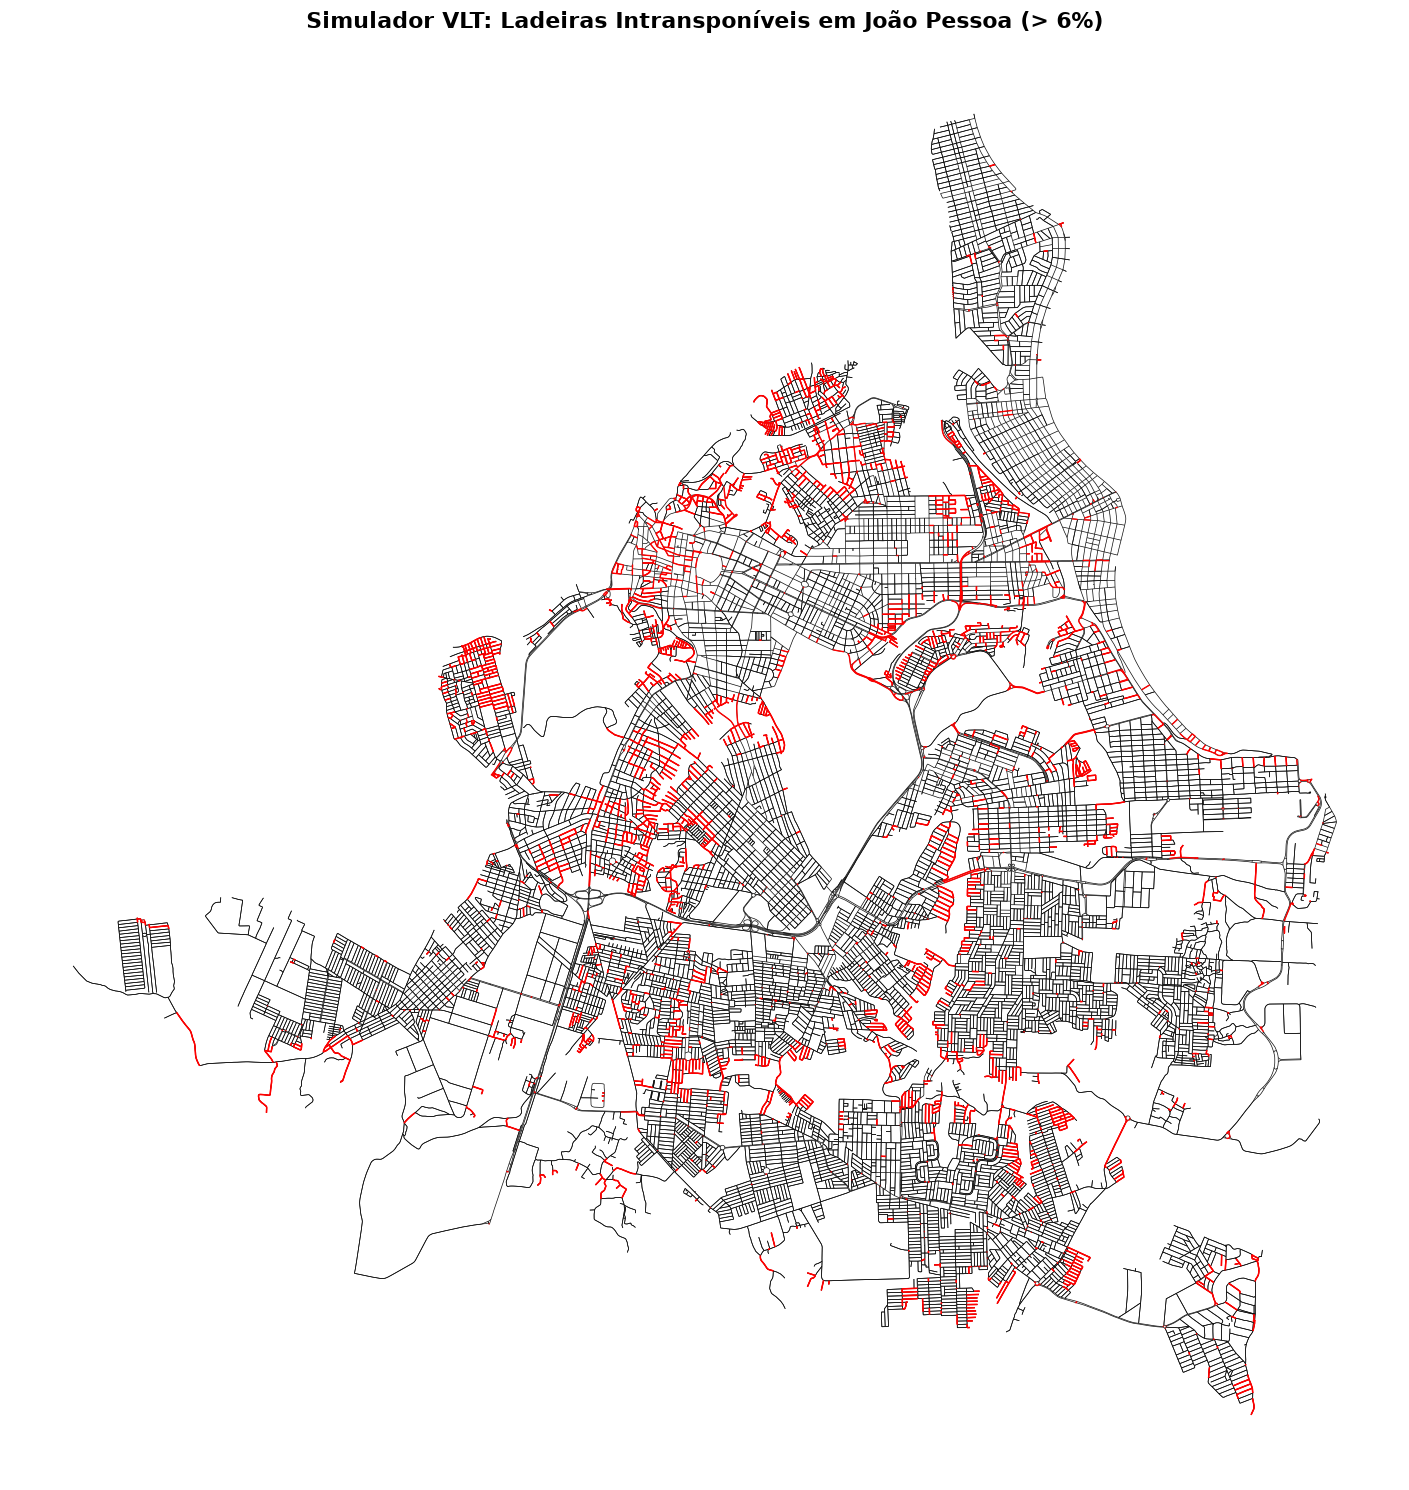

In [35]:
# 1. Filtra APENAS as ruas que foram barradas pelo limite de inclinação de 6%
ladeiras_proibidas = arestas[(arestas['inclinacao_1'] > 6.0) | (arestas['inclinacao_2'] > 6.0)]

# 2. Criando a tela do gráfico (15 de largura por 15 de altura para vermos a cidade toda)
fig, ax = plt.subplots(figsize=(15, 15))

# 3. Camada Base: Plota TODAS as ruas de João Pessoa em cinza bem claro e fino
arestas.plot(ax=ax, color="#0c0c0c", linewidth=0.5, zorder=1)

# 4. Camada de Destaque: Plota as ladeiras por cima, em vermelho e mais grossas
ladeiras_proibidas.plot(ax=ax, color='red', linewidth=1.0, zorder=2)

# 5. Estilizando o mapa para ficar profissional
plt.title('Simulador VLT: Ladeiras Intransponíveis em João Pessoa (> 6%)', fontsize=16, fontweight='bold', pad=15)
plt.axis('off') # Esconde a régua de coordenadas das bordas para focar só no mapa

# Mostra o mapa na tela
plt.tight_layout()
plt.show()

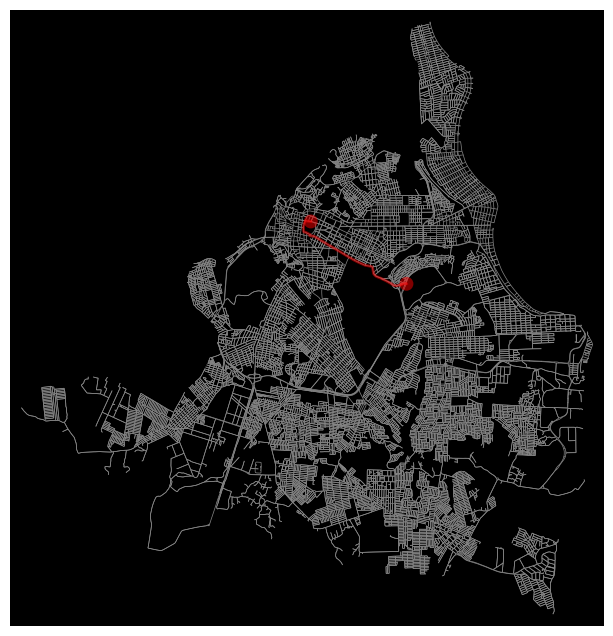

In [36]:
# Dados da origem e destino
origin_lat = -7.118200
origin_lon = -34.87949

destination_lat = -7.13746
destination_lon = -34.85040

origin_node = ox.distance.nearest_nodes(grafo_ruas, origin_lon, origin_lat)
destination_node = ox.distance.nearest_nodes(grafo_ruas, destination_lon, destination_lat)

route = nx.shortest_path(grafo_ruas, origin_node, destination_node, weight='length')

fig, ax = ox.plot_graph_route(
    grafo_ruas, route, 
    route_color='red', 
    route_linewidth=2,        # Afina a linha do VLT
    node_size=0,              # Esconde as bolinhas dos cruzamentos
    bgcolor='black',          # Fundo branco
    edge_color="#888888",     # Ruas de fundo bem clarinhas
    edge_linewidth=0.5        # Ruas de fundo bem finas
)

In [37]:
import folium

# 1. Extrai as coordenadas (Lat, Lng) de cada esquina que o algoritmo escolheu
coordenadas_rota = [(grafo_ruas.nodes[no]['y'], grafo_ruas.nodes[no]['x']) for no in route]

# 2. Criamos o mapa interativo do Folium (igual ao seu projeto antigo)
mapa_vlt = folium.Map(location=[origin_lat, origin_lon], zoom_start=13)

# 3. Desenha a linha do VLT acompanhando perfeitamente as ruas
folium.PolyLine(
    locations=coordenadas_rota, 
    color='red', 
    weight=5, 
    tooltip='Rota Otimizada do VLT'
).add_to(mapa_vlt)

# 4. Adiciona os marcadores de Origem e Destino
folium.Marker([origin_lat, origin_lon], popup='Centro (Lagoa)', icon=folium.Icon(color='green', icon='train', prefix='fa')).add_to(mapa_vlt)
folium.Marker([destination_lat, destination_lon], popup='Bancários/UFPB', icon=folium.Icon(color='blue', icon='train', prefix='fa')).add_to(mapa_vlt)

mapa_vlt